In [1]:
# Data Preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("healthcare_operations_patient_analytics_raw_messy.csv")

In [4]:
df.head()

,Patient_ID,Patient_Name,Age,Gender,Blood_Group,City,State,Department,Doctor,Medical_Condition,...,Patient_Payment,Patient_Satisfaction,Outcome,Follow_Up_Required,Readmission_Within_30_Days,Age_Group,Admission_Year,Admission_Month,Admission_Month_Name,Quarter
0,PAT00001,Rahul Gupta,22,Female,B+,Kolkata,West Bengal,Orthopedics,Dr. Gupta,Fracture,...,2993.81,5.0,Stable,No,No,18-35,2025,4,April,Q2
1,PAT00002,Kavya Reddy,66,Male,O-,Mumbai,Maharashtra,General Medicine,Dr. Gupta,Routine Checkup,...,68763.66,4.0,Transferred,Yes,No,66+,2025,9,September,Q3
2,PAT00003,Pooja Joshi,89,Female,A+,Ahmedabad,Gujarat,Dermatology,Dr. Sharma,Routine Checkup,...,19174.47,4.0,Recovered,Yes,No,66+,2025,5,May,Q2
3,PAT00004,Aarav Singh,78,Male,A-,Delhi,Delhi,Neurology,Dr. Sharma,Asthma,...,11507.17,3.8,Recovered,No,No,66+,2025,10,October,Q4
4,PAT00005,Nisha Patel,83,Male,AB-,Kolkata,West Bengal,Neurology,Dr. Kumar,Heart Disease,...,9271.42,4.3,Recovered,Yes,No,66+,2026,1,January,Q1


In [6]:
df.tail()

,Patient_ID,Patient_Name,Age,Gender,Blood_Group,City,State,Department,Doctor,Medical_Condition,...,Patient_Payment,Patient_Satisfaction,Outcome,Follow_Up_Required,Readmission_Within_30_Days,Age_Group,Admission_Year,Admission_Month,Admission_Month_Name,Quarter
10030,PAT09637,Neha Kumar,37,Female,A+,Bengaluru,Karnataka,Oncology,Dr. Nair,Skin Infection,...,51873.64,4.4,Recovered,No,No,36-50,2025,3,March,Q1
10031,PAT01016,Aditya Singh,43,Female,B-,Jaipur,Rajasthan,Emergency,Dr. Verma,Asthma,...,2668.39,3.1,Recovered,Yes,No,36-50,2025,6,June,Q2
10032,PAT08922,Rahul Singh,88,Female,A-,Jaipur,Rajasthan,Neurology,Dr. Sharma,Skin Infection,...,9137.46,4.0,Recovered,No,Yes,66+,2025,5,May,Q2
10033,PAT03045,Ishita Reddy,49,Male,A-,Ahmedabad,Gujarat,Cardiology,Dr. Joshi,Pneumonia,...,10231.90,3.5,Recovered,Yes,No,36-50,2025,7,July,Q3
10034,PAT03499,Vikram Verma,68,Male,O-,Pune,Maharashtra,Oncology,Dr. Verma,Skin Infection,...,0.00,4.9,Recovered,No,No,66+,2025,5,May,Q2


In [7]:
df.shape

(10035, 28)

In [8]:
df.columns

Index(['Patient_ID', 'Patient_Name', 'Age', 'Gender', 'Blood_Group', 'City',
       'State', 'Department', 'Doctor', 'Medical_Condition', 'Admission_Type',
       'Admission_Date', 'Discharge_Date', 'Length_of_Stay_Days', 'Room_Type',
       'Insurance_Type', 'Treatment_Cost', 'Insurance_Covered',
       'Patient_Payment', 'Patient_Satisfaction', 'Outcome',
       'Follow_Up_Required', 'Readmission_Within_30_Days', 'Age_Group',
       'Admission_Year', 'Admission_Month', 'Admission_Month_Name', 'Quarter'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10035 entries, 0 to 10034
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient_ID                  10035 non-null  object 
 1   Patient_Name                10035 non-null  object 
 2   Age                         10035 non-null  int64  
 3   Gender                      10035 non-null  object 
 4   Blood_Group                 10035 non-null  object 
 5   City                        10035 non-null  object 
 6   State                       10035 non-null  object 
 7   Department                  10035 non-null  object 
 8   Doctor                      10035 non-null  object 
 9   Medical_Condition           10035 non-null  object 
 10  Admission_Type              10035 non-null  object 
 11  Admission_Date              10035 non-null  object 
 12  Discharge_Date              10035 non-null  object 
 13  Length_of_Stay_Days         100

In [10]:
df.isnull().sum()

Patient_ID                     0
Patient_Name                   0
Age                            0
Gender                         0
Blood_Group                    0
City                           0
State                          0
Department                     0
Doctor                         0
Medical_Condition              0
Admission_Type                 0
Admission_Date                 0
Discharge_Date                 0
Length_of_Stay_Days            0
Room_Type                      0
Insurance_Type                45
Treatment_Cost                 0
Insurance_Covered              0
Patient_Payment                0
Patient_Satisfaction          30
Outcome                        0
Follow_Up_Required             0
Readmission_Within_30_Days     0
Age_Group                      0
Admission_Year                 0
Admission_Month                0
Admission_Month_Name           0
Quarter                        0
dtype: int64

In [11]:
df.duplicated().sum()

35

In [12]:
df["Patient_ID"].duplicated().sum()

35

In [13]:
df["Patient_ID"].nunique()

10000

In [15]:
df.describe()

,Age,Length_of_Stay_Days,Insurance_Covered,Patient_Payment,Patient_Satisfaction,Admission_Year,Admission_Month
count,10035.000000,10035.000000,10035.000000,10035.000000,10005.000000,10035.000000,10035.000000
mean,45.209367,5.236074,28884.866747,12402.212977,3.978061,2025.330842,5.495566
std,25.862786,3.374855,23720.606431,17139.385898,0.655574,0.470540,3.297708
min,1.000000,1.000000,0.000000,0.000000,1.300000,2025.000000,1.000000
25%,23.000000,3.000000,15662.340000,2524.190000,3.500000,2025.000000,3.000000
50%,45.000000,4.000000,26222.200000,6173.910000,4.000000,2025.000000,5.000000
75%,67.000000,7.000000,38173.005000,15304.660000,4.500000,2026.000000,8.000000
max,90.000000,30.000000,343261.470000,187170.580000,5.000000,2026.000000,12.000000


In [16]:
df["Gender"].value_counts(dropna=False)

Gender
Male      4992
Female    4797
Other      226
M           20
Name: count, dtype: int64

In [17]:
df["City"].value_counts(dropna=False)

City
Hyderabad    1054
Kochi        1038
Pune         1023
Kolkata      1017
Chennai       995
Jaipur        995
Bengaluru     986
Mumbai        974
Ahmedabad     967
Delhi         961
chennai         4
ahmedabad       4
jaipur          4
delhi           3
bengaluru       3
pune            3
hyderabad       2
kolkata         2
Name: count, dtype: int64

In [18]:
df["Insurance_Type"].value_counts(dropna=False)

Insurance_Type
Private Insurance       4207
Government Insurance    3048
Self Pay                1740
Corporate Insurance      995
NaN                       45
Name: count, dtype: int64

In [19]:
df["Treatment_Cost"].head(20)

0      29938.08
1      68763.66
2      19174.47
3      38357.24
4      46357.08
5     107854.41
6      44714.16
7      23738.87
8      51367.11
9      34558.85
10     51269.66
11     54214.97
12     26790.58
13     36254.56
14     14009.51
15      17705.9
16     70492.68
17     31082.45
18     48159.94
19     23621.26
Name: Treatment_Cost, dtype: object

In [20]:
df[["Admission_Date", "Discharge_Date"]].head()

,Admission_Date,Discharge_Date
0,2025-04-25,2025-04-26
1,2025-09-16,2025-10-01
2,2025-05-02,2025-05-04
3,2025-10-26,2025-10-30
4,2026-01-16,2026-01-21


In [21]:
quality_report = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing_Values": df.isnull().sum().values,
    "Unique_Values": df.nunique().values
})

quality_report

,Column,Data_Type,Missing_Values,Unique_Values
0,Patient_ID,object,0,10000
1,Patient_Name,object,0,240
2,Age,int64,0,90
3,Gender,object,0,4
4,Blood_Group,object,0,8
5,City,object,0,18
6,State,object,0,9
7,Department,object,0,8
8,Doctor,object,0,12
9,Medical_Condition,object,0,10


In [22]:
df_raw = df.copy()

In [23]:
df = df.drop_duplicates()

In [24]:
df.shape

(10000, 28)

In [25]:
df.duplicated().sum()

0

In [27]:
df["Gender"] = df["Gender"].replace({
    "M": "Male"
})
df["Gender"].value_counts()

Gender
Male      4997
Female    4777
Other      226
Name: count, dtype: int64

In [29]:
df["City"] = df["City"].str.strip().str.title()
df["City"].value_counts()

City
Hyderabad    1053
Kochi        1034
Pune         1021
Kolkata      1017
Chennai       996
Jaipur        994
Bengaluru     985
Mumbai        971
Ahmedabad     967
Delhi         962
Name: count, dtype: int64

In [30]:
df["Treatment_Cost"] = (
    df["Treatment_Cost"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
)

In [33]:
df["Treatment_Cost"] = pd.to_numeric(
    df["Treatment_Cost"],
    errors="coerce"
)

In [34]:
df["Treatment_Cost"].dtype

dtype('float64')

In [35]:
df["Admission_Date"] = pd.to_datetime(
    df["Admission_Date"],
    errors="coerce"
)

df["Discharge_Date"] = pd.to_datetime(
    df["Discharge_Date"],
    errors="coerce"
)

In [36]:
df[["Admission_Date", "Discharge_Date"]].dtypes

Admission_Date    datetime64[ns]
Discharge_Date    datetime64[ns]
dtype: object

In [37]:
df["Insurance_Type"] = df["Insurance_Type"].fillna("Unknown")

In [38]:
df["Insurance_Type"].isnull().sum()

0

In [39]:
median_satisfaction = df["Patient_Satisfaction"].median()

In [40]:
df["Patient_Satisfaction"] = df["Patient_Satisfaction"].fillna(
    median_satisfaction
)

In [42]:
df["Patient_Satisfaction"].isnull().sum()

0

In [43]:
df.isnull().sum()

Patient_ID                    0
Patient_Name                  0
Age                           0
Gender                        0
Blood_Group                   0
City                          0
State                         0
Department                    0
Doctor                        0
Medical_Condition             0
Admission_Type                0
Admission_Date                0
Discharge_Date                0
Length_of_Stay_Days           0
Room_Type                     0
Insurance_Type                0
Treatment_Cost                0
Insurance_Covered             0
Patient_Payment               0
Patient_Satisfaction          0
Outcome                       0
Follow_Up_Required            0
Readmission_Within_30_Days    0
Age_Group                     0
Admission_Year                0
Admission_Month               0
Admission_Month_Name          0
Quarter                       0
dtype: int64

In [44]:
df["Age"].min(), df["Age"].max()

(1, 90)

In [45]:
df[df["Age"] < 0]

,Patient_ID,Patient_Name,Age,Gender,Blood_Group,City,State,Department,Doctor,Medical_Condition,...,Patient_Payment,Patient_Satisfaction,Outcome,Follow_Up_Required,Readmission_Within_30_Days,Age_Group,Admission_Year,Admission_Month,Admission_Month_Name,Quarter


In [46]:
df["Length_of_Stay_Days"].min()

1

In [47]:
df[df["Length_of_Stay_Days"] <= 0]

,Patient_ID,Patient_Name,Age,Gender,Blood_Group,City,State,Department,Doctor,Medical_Condition,...,Patient_Payment,Patient_Satisfaction,Outcome,Follow_Up_Required,Readmission_Within_30_Days,Age_Group,Admission_Year,Admission_Month,Admission_Month_Name,Quarter


In [48]:
df["Patient_Satisfaction"].min(), df["Patient_Satisfaction"].max()

(1.3, 5.0)

In [49]:
df[
    (df["Patient_Satisfaction"] < 1) |
    (df["Patient_Satisfaction"] > 5)
]

,Patient_ID,Patient_Name,Age,Gender,Blood_Group,City,State,Department,Doctor,Medical_Condition,...,Patient_Payment,Patient_Satisfaction,Outcome,Follow_Up_Required,Readmission_Within_30_Days,Age_Group,Admission_Year,Admission_Month,Admission_Month_Name,Quarter


In [50]:
df["Treatment_Cost"].min()

2500.0

In [51]:
df["Patient_Payment"].min()

0.0

In [52]:
df.shape

(10000, 28)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Patient_ID                  10000 non-null  object        
 1   Patient_Name                10000 non-null  object        
 2   Age                         10000 non-null  int64         
 3   Gender                      10000 non-null  object        
 4   Blood_Group                 10000 non-null  object        
 5   City                        10000 non-null  object        
 6   State                       10000 non-null  object        
 7   Department                  10000 non-null  object        
 8   Doctor                      10000 non-null  object        
 9   Medical_Condition           10000 non-null  object        
 10  Admission_Type              10000 non-null  object        
 11  Admission_Date              10000 non-null  datetime64[ns]
 

In [54]:
df.isnull().sum().sum()

0

In [55]:
df.duplicated().sum()

0

In [57]:
df.to_csv(
    "healthcare_operations_patient_analytics_clean.csv",
    index=False
)

In [58]:
# Exploratory Data Analysis (EDA)

# 1.Gender Distribution
gender_counts = df["Gender"].value_counts()
gender_counts

Gender
Male      4997
Female    4777
Other      226
Name: count, dtype: int64

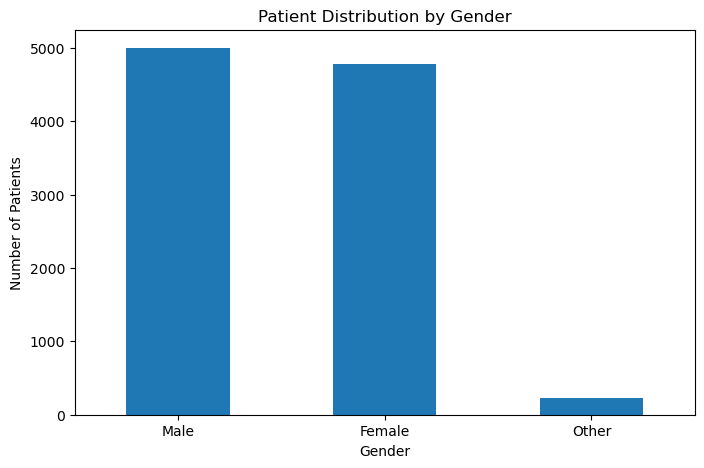

In [60]:
plt.figure(figsize=(8,5))
gender_counts.plot(kind="bar")
plt.title("Patient Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

In [61]:
# 2.Age Analysis
df["Age"].describe()

count    10000.000000
mean        45.191000
std         25.858902
min          1.000000
25%         23.000000
50%         45.000000
75%         67.000000
max         90.000000
Name: Age, dtype: float64

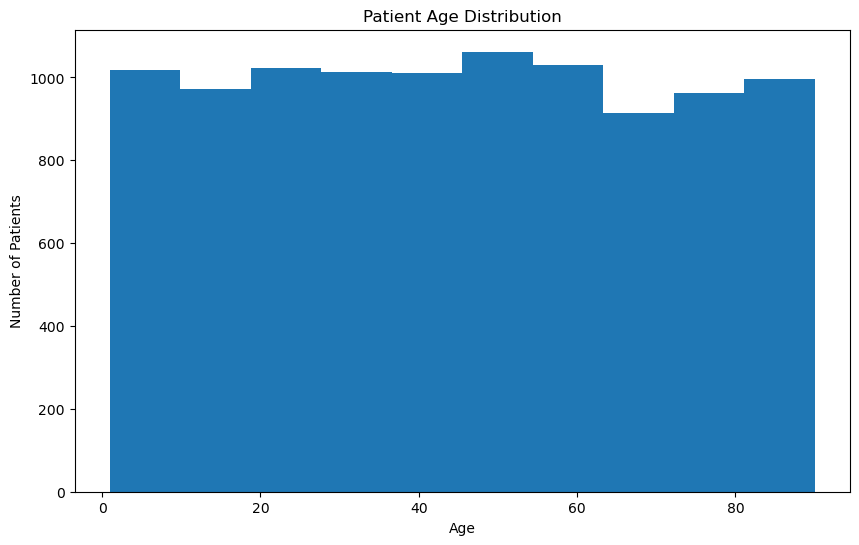

In [64]:
plt.figure(figsize=(10,6))
plt.hist(df["Age"], bins=10)
plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

In [65]:
# 3.Age Group Analysis
age_group_counts = df["Age_Group"].value_counts().sort_index()
age_group_counts

Age_Group
0-17     1866
18-35    2043
36-50    1733
51-65    1695
66+      2663
Name: count, dtype: int64

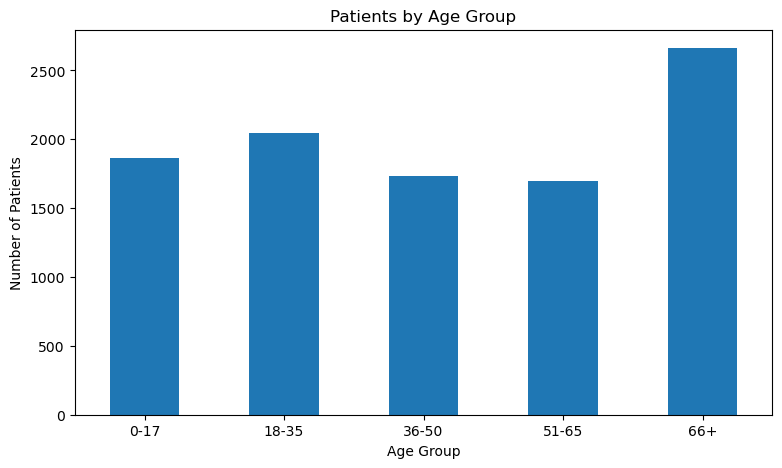

In [67]:
plt.figure(figsize=(9,5))
age_group_counts.plot(kind="bar")
plt.title("Patients by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

In [68]:
# 4.Department Analysis
department_counts = df["Department"].value_counts()
department_counts

Department
General Medicine    1992
Emergency           1496
Orthopedics         1461
Neurology           1275
Cardiology          1137
Pediatrics          1001
Dermatology          841
Oncology             797
Name: count, dtype: int64

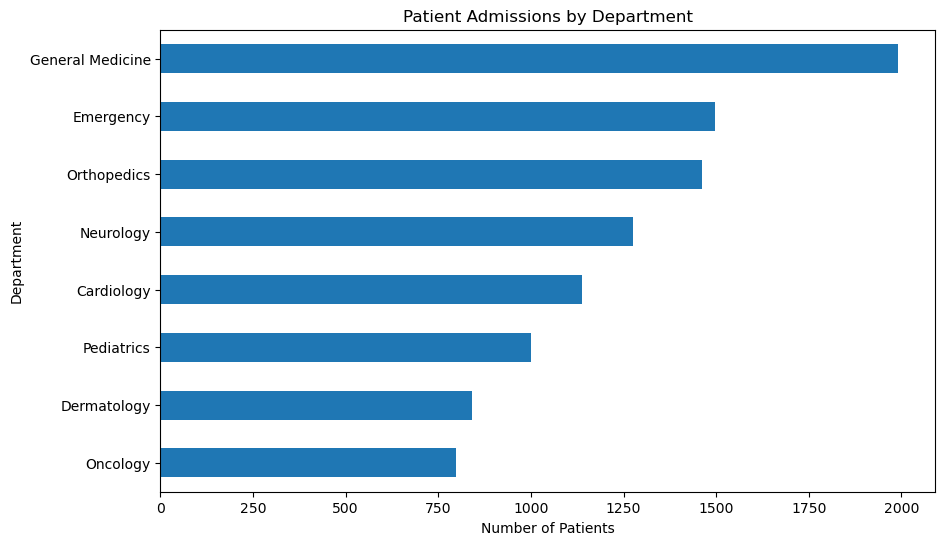

In [69]:
plt.figure(figsize=(10,6))
department_counts.sort_values().plot(kind="barh")
plt.title("Patient Admissions by Department")
plt.xlabel("Number of Patients")
plt.ylabel("Department")
plt.show()

In [70]:
# 5.Medical Condition Analysis
condition_counts = df["Medical_Condition"].value_counts()
condition_counts

Medical_Condition
Heart Disease      1039
Hypertension       1032
Pneumonia          1016
Skin Infection     1004
Asthma             1003
Migraine           1001
Routine Checkup     995
Diabetes            994
Fracture            958
Cancer              958
Name: count, dtype: int64

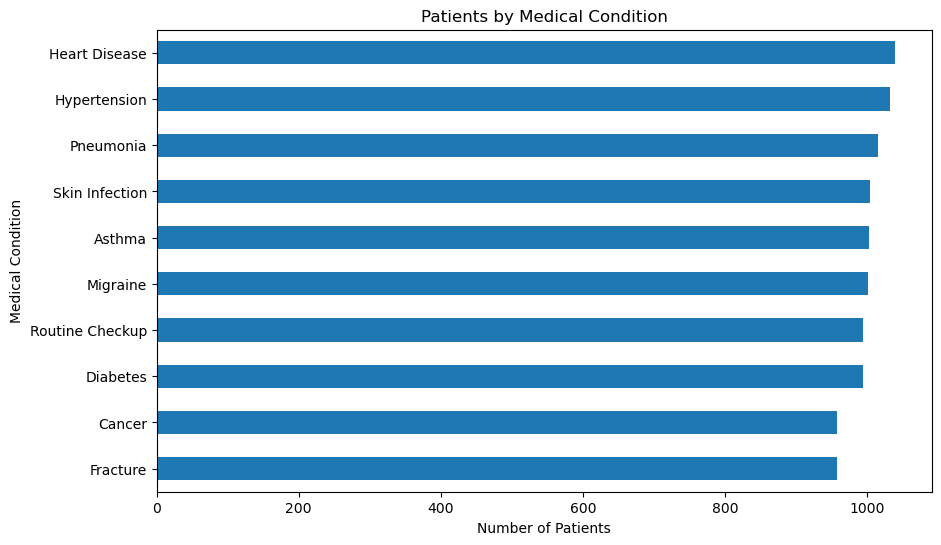

In [71]:
plt.figure(figsize=(10,6))
condition_counts.sort_values().plot(kind="barh")
plt.title("Patients by Medical Condition")
plt.xlabel("Number of Patients")
plt.ylabel("Medical Condition")
plt.show()

In [72]:
# 6.Admission Type
admission_type_counts = df["Admission_Type"].value_counts()
admission_type_counts

Admission_Type
Elective     4584
Emergency    2888
Urgent       2528
Name: count, dtype: int64

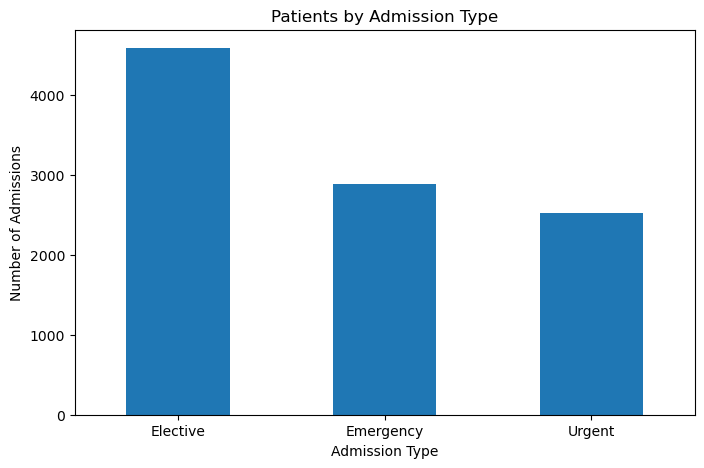

In [73]:
plt.figure(figsize=(8,5))
admission_type_counts.plot(kind="bar")
plt.title("Patients by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=0)
plt.show()

In [74]:
# 7.Monthly Admission Trend
monthly_admissions = (
    df.groupby(["Admission_Year", "Admission_Month"])
      .size()
      .reset_index(name="Admissions")
)

monthly_admissions

,Admission_Year,Admission_Month,Admissions
0,2025,1,589
1,2025,2,515
2,2025,3,593
3,2025,4,548
4,2025,5,542
5,2025,6,552
6,2025,7,543
7,2025,8,587
8,2025,9,589
9,2025,10,563


In [75]:
monthly_admissions["Month_Date"] = pd.to_datetime(
    monthly_admissions["Admission_Year"].astype(str)
    + "-"
    + monthly_admissions["Admission_Month"].astype(str)
    + "-01"
)

In [76]:
monthly_admissions = monthly_admissions.sort_values("Month_Date")

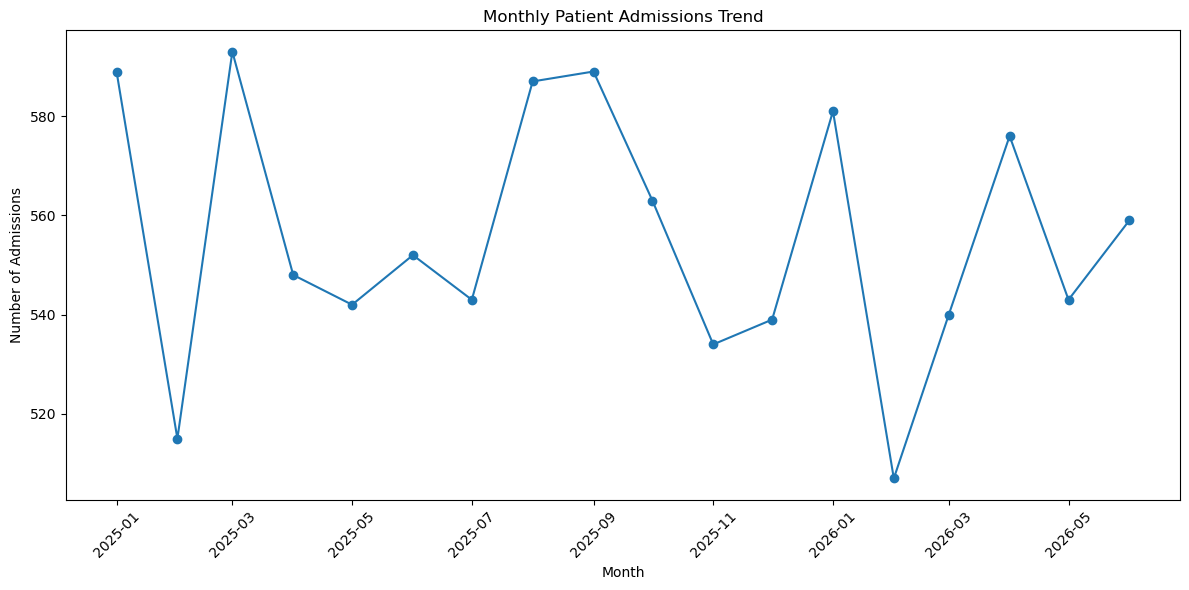

In [77]:
plt.figure(figsize=(12,6))
plt.plot(
    monthly_admissions["Month_Date"],
    monthly_admissions["Admissions"],
    marker="o"
)
plt.title("Monthly Patient Admissions Trend")
plt.xlabel("Month")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [78]:
# 8.Length of Stay
df["Length_of_Stay_Days"].describe()

count    10000.000000
mean         5.237800
std          3.375676
min          1.000000
25%          3.000000
50%          4.000000
75%          7.000000
max         30.000000
Name: Length_of_Stay_Days, dtype: float64

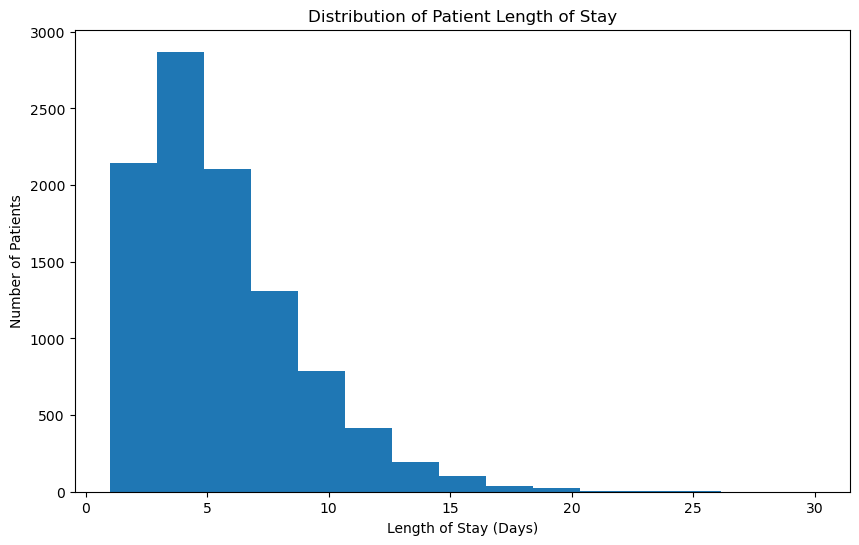

In [79]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Length_of_Stay_Days"],
    bins=15
)

plt.title("Distribution of Patient Length of Stay")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Number of Patients")

plt.show()

In [80]:
# 9.Average Length of Stay by Department
avg_los_department = (
    df.groupby("Department")["Length_of_Stay_Days"]
      .mean()
      .sort_values(ascending=False)
)

avg_los_department

Department
Cardiology          5.345646
General Medicine    5.281627
Dermatology         5.248514
Pediatrics          5.239760
Neurology           5.209412
Emergency           5.200535
Orthopedics         5.185489
Oncology            5.171895
Name: Length_of_Stay_Days, dtype: float64

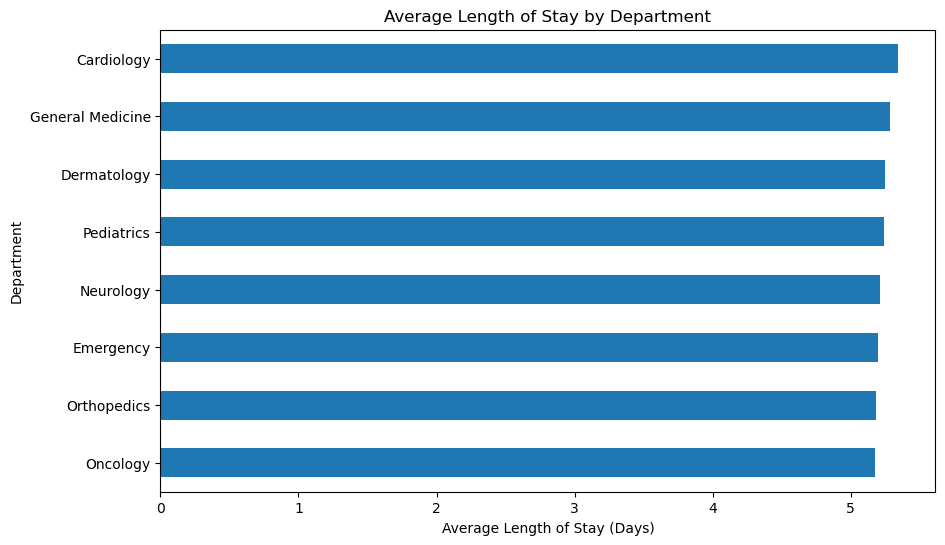

In [81]:
plt.figure(figsize=(10,6))
avg_los_department.sort_values().plot(kind="barh")
plt.title("Average Length of Stay by Department")
plt.xlabel("Average Length of Stay (Days)")
plt.ylabel("Department")
plt.show()

In [82]:
# 10.Treatment Cost Analysis
df["Treatment_Cost"].describe()

count     10000.000000
mean      41301.931443
std       24424.159972
min        2500.000000
25%       26722.292500
50%       35513.160000
75%       48671.920000
max      365400.270000
Name: Treatment_Cost, dtype: float64

In [83]:
total_treatment_cost = df["Treatment_Cost"].sum()
total_treatment_cost

413019314.43

In [84]:
average_treatment_cost = df["Treatment_Cost"].mean()
average_treatment_cost

41301.931443

In [85]:
median_treatment_cost = df["Treatment_Cost"].median()
median_treatment_cost

35513.16

In [86]:
# 11.Treatment Cost by Department
cost_by_department = (
    df.groupby("Department")["Treatment_Cost"]
      .sum()
      .sort_values(ascending=False)
)

cost_by_department

Department
General Medicine    67600451.27
Neurology           61567474.22
Orthopedics         61541859.69
Emergency           60051446.24
Cardiology          59926218.68
Oncology            45583892.56
Pediatrics          32394002.18
Dermatology         24353969.59
Name: Treatment_Cost, dtype: float64

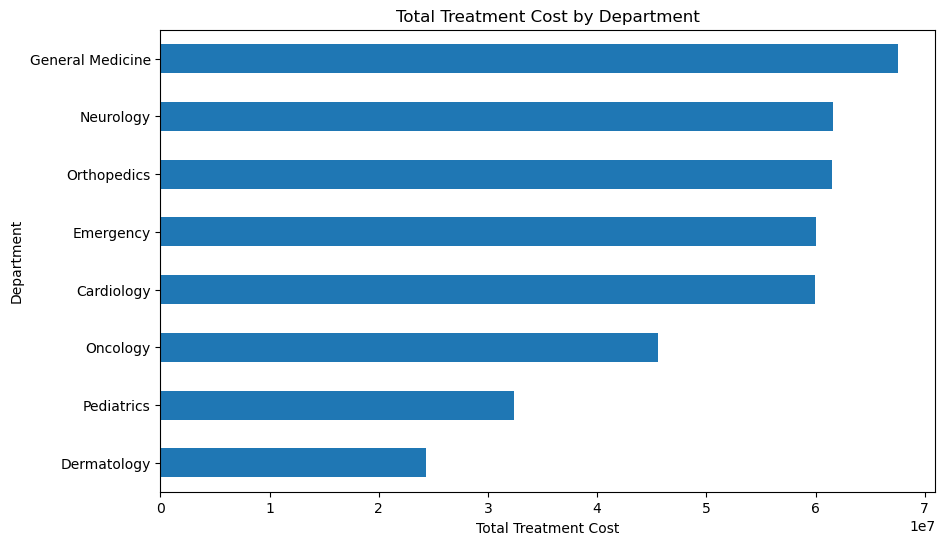

In [87]:
plt.figure(figsize=(10,6))

cost_by_department.sort_values().plot(kind="barh")

plt.title("Total Treatment Cost by Department")
plt.xlabel("Total Treatment Cost")
plt.ylabel("Department")

plt.show()

In [88]:
# 12.Insurance Analysis
insurance_counts = df["Insurance_Type"].value_counts()
insurance_counts

Insurance_Type
Private Insurance       4193
Government Insurance    3039
Self Pay                1730
Corporate Insurance      993
Unknown                   45
Name: count, dtype: int64

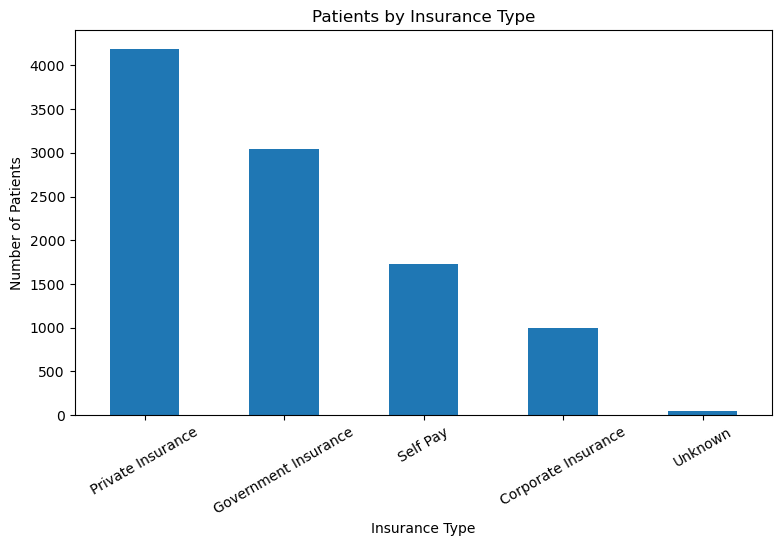

In [90]:
plt.figure(figsize=(9,5))
insurance_counts.plot(kind="bar")
plt.title("Patients by Insurance Type")
plt.xlabel("Insurance Type")
plt.ylabel("Number of Patients")
plt.xticks(rotation=30)
plt.show()

In [91]:
# 13. Insurance Coverage Analysis
total_insurance_covered = df["Insurance_Covered"].sum()
total_insurance_covered

289027591.39

In [92]:
total_patient_payment = df["Patient_Payment"].sum()
total_patient_payment

123991722.61000001

In [93]:
coverage_summary = pd.DataFrame({
    "Amount": [
        total_insurance_covered,
        total_patient_payment
    ]
}, index=[
    "Insurance Covered",
    "Patient Payment"
])

coverage_summary

,Amount
Insurance Covered,2.890276e+08
Patient Payment,1.239917e+08


In [94]:
# 14. Patient Satisfaction
df["Patient_Satisfaction"].describe()

count    10000.00000
mean         3.97817
std          0.65460
min          1.30000
25%          3.50000
50%          4.00000
75%          4.50000
max          5.00000
Name: Patient_Satisfaction, dtype: float64

In [95]:
average_satisfaction = df["Patient_Satisfaction"].mean()
average_satisfaction

3.9781699999999995

In [96]:
satisfaction_counts = df["Patient_Satisfaction"].value_counts().sort_index()
satisfaction_counts

Patient_Satisfaction
1.3      1
1.4      2
1.6      2
1.7      3
1.8      2
1.9      1
2.0      7
2.1     15
2.2     12
2.3     31
2.4     41
2.5     67
2.6     89
2.7     99
2.8    122
2.9    167
3.0    208
3.1    282
3.2    271
3.3    364
3.4    396
3.5    433
3.6    484
3.7    502
3.8    544
3.9    526
4.0    585
4.1    597
4.2    500
4.3    515
4.4    517
4.5    449
4.6    384
4.7    356
4.8    300
4.9    239
5.0    887
Name: count, dtype: int64

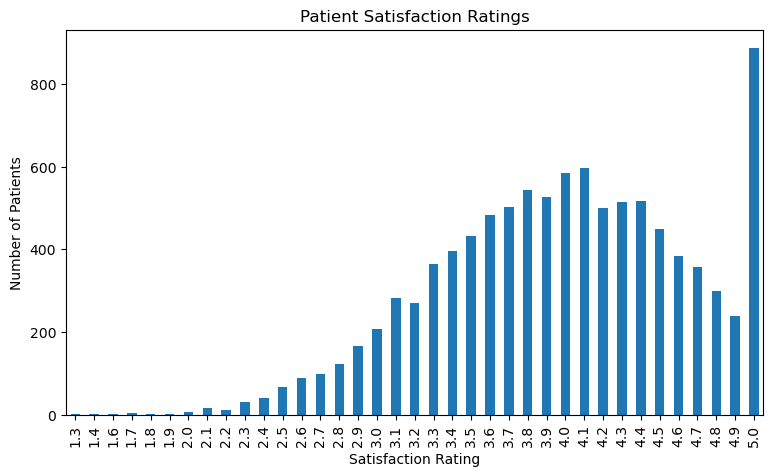

In [97]:
plt.figure(figsize=(9,5))
satisfaction_counts.plot(kind="bar")
plt.title("Patient Satisfaction Ratings")
plt.xlabel("Satisfaction Rating")
plt.ylabel("Number of Patients")
plt.show()

In [98]:
# 15.Patient Outcomes
outcome_counts = df["Outcome"].value_counts()
outcome_counts

Outcome
Recovered      4794
Improved       2986
Stable         1610
Transferred     479
Expired         131
Name: count, dtype: int64

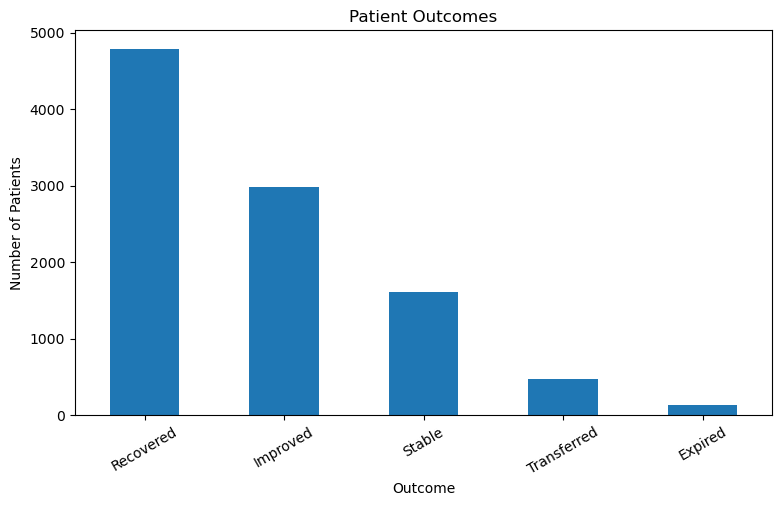

In [99]:
plt.figure(figsize=(9,5))
outcome_counts.plot(kind="bar")
plt.title("Patient Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.xticks(rotation=30)

plt.show()

In [100]:
# 16.Calculate Outcome Percentages
outcome_percentage = (
    df["Outcome"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

outcome_percentage

Outcome
Recovered      47.94
Improved       29.86
Stable         16.10
Transferred     4.79
Expired         1.31
Name: proportion, dtype: float64

In [101]:
# 17.Readmission Analysis
readmission_counts = df["Readmission_Within_30_Days"].value_counts()
readmission_counts

Readmission_Within_30_Days
No     9107
Yes     893
Name: count, dtype: int64

In [105]:
readmission_rate = (
    df["Readmission_Within_30_Days"]
    .eq("Yes")
    .mean() * 100
)

readmission_rate

8.93

In [106]:
# 18.Follow-Up Analysis
followup_counts = df["Follow_Up_Required"].value_counts()
followup_counts

Follow_Up_Required
No     5747
Yes    4253
Name: count, dtype: int64

In [107]:
followup_rate = (
    df["Follow_Up_Required"]
    .eq("Yes")
    .mean() * 100
)

followup_rate

42.53

In [108]:
# 19.City Analysis
city_counts = df["City"].value_counts()
city_counts

City
Hyderabad    1053
Kochi        1034
Pune         1021
Kolkata      1017
Chennai       996
Jaipur        994
Bengaluru     985
Mumbai        971
Ahmedabad     967
Delhi         962
Name: count, dtype: int64

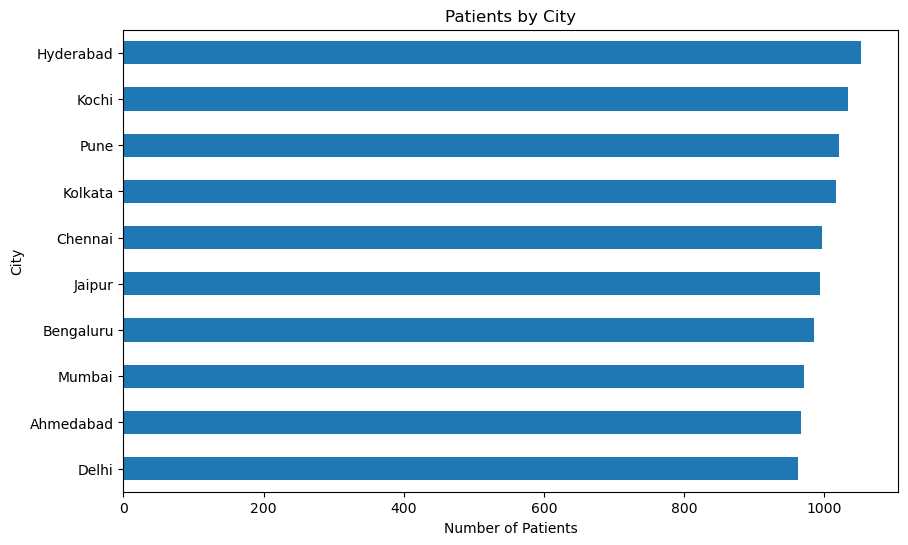

In [109]:
plt.figure(figsize=(10,6))

city_counts.sort_values().plot(kind="barh")

plt.title("Patients by City")
plt.xlabel("Number of Patients")
plt.ylabel("City")

plt.show()

In [110]:
# 20.Department Performance Table
department_analysis = (
    df.groupby("Department")
      .agg(
          Total_Patients=("Patient_ID", "count"),
          Avg_Length_of_Stay=("Length_of_Stay_Days", "mean"),
          Total_Treatment_Cost=("Treatment_Cost", "sum"),
          Avg_Treatment_Cost=("Treatment_Cost", "mean"),
          Avg_Satisfaction=("Patient_Satisfaction", "mean")
      )
      .round(2)
      .sort_values("Total_Patients", ascending=False)
)

department_analysis

,Total_Patients,Avg_Length_of_Stay,Total_Treatment_Cost,Avg_Treatment_Cost,Avg_Satisfaction
Department,,,,,
General Medicine,1992,5.28,67600451.27,33935.97,3.97
Emergency,1496,5.20,60051446.24,40141.34,3.93
Orthopedics,1461,5.19,61541859.69,42123.11,4.02
Neurology,1275,5.21,61567474.22,48288.22,3.97
Cardiology,1137,5.35,59926218.68,52705.56,3.96
Pediatrics,1001,5.24,32394002.18,32361.64,3.98
Dermatology,841,5.25,24353969.59,28958.35,4.00
Oncology,797,5.17,45583892.56,57194.34,4.02


In [111]:
# 21.Correlaton Analysis
correlation = df[
    [
        "Age",
        "Length_of_Stay_Days",
        "Treatment_Cost",
        "Insurance_Covered",
        "Patient_Payment",
        "Patient_Satisfaction"
    ]
].corr()

correlation

,Age,Length_of_Stay_Days,Treatment_Cost,Insurance_Covered,Patient_Payment,Patient_Satisfaction
Age,1.000000,-0.020377,-0.005507,-0.009010,0.004635,-0.007365
Length_of_Stay_Days,-0.020377,1.000000,0.663474,0.474256,0.288740,0.003001
Treatment_Cost,-0.005507,0.663474,1.000000,0.747427,0.389982,-0.005283
Insurance_Covered,-0.009010,0.474256,0.747427,1.000000,-0.320261,-0.001741
Patient_Payment,0.004635,0.288740,0.389982,-0.320261,1.000000,-0.005120
Patient_Satisfaction,-0.007365,0.003001,-0.005283,-0.001741,-0.005120,1.000000


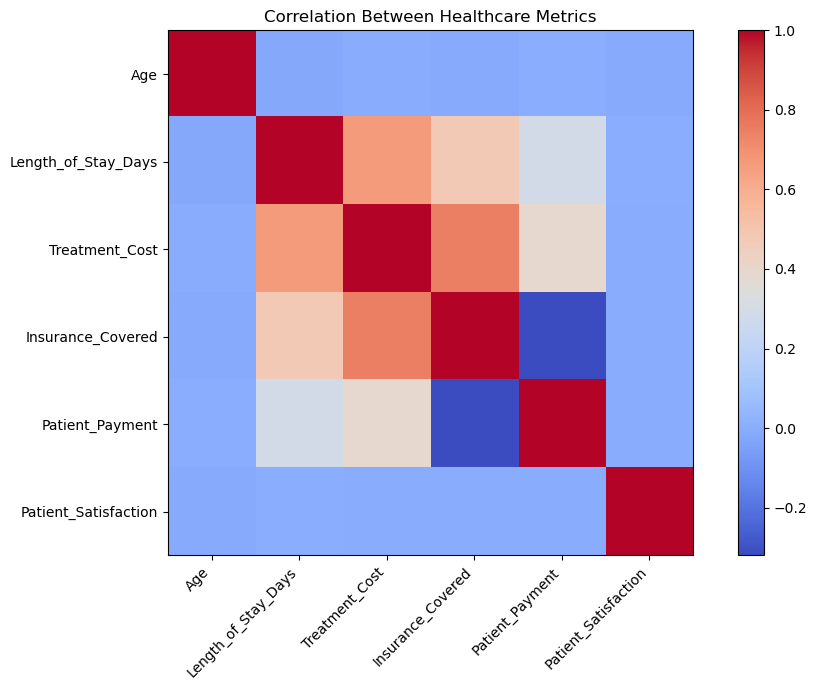

In [112]:
plt.figure(figsize=(10,7))

plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Between Healthcare Metrics")

plt.tight_layout()
plt.show()

In [113]:
# 22.Creating Own KPI Values
total_patients = df["Patient_ID"].nunique()

total_admissions = len(df)

total_treatment_cost = df["Treatment_Cost"].sum()

avg_length_of_stay = df["Length_of_Stay_Days"].mean()

avg_treatment_cost = df["Treatment_Cost"].mean()

avg_satisfaction = df["Patient_Satisfaction"].mean()

readmission_rate = (
    df["Readmission_Within_30_Days"].eq("Yes").mean() * 100
)

followup_rate = (
    df["Follow_Up_Required"].eq("Yes").mean() * 100
)

print("Total Patients:", total_patients)
print("Total Admissions:", total_admissions)
print("Total Treatment Cost:", round(total_treatment_cost, 2))
print("Average Length of Stay:", round(avg_length_of_stay, 2))
print("Average Treatment Cost:", round(avg_treatment_cost, 2))
print("Average Satisfaction:", round(avg_satisfaction, 2))
print("30-Day Readmission Rate:", round(readmission_rate, 2), "%")
print("Follow-Up Rate:", round(followup_rate, 2), "%")

Total Patients: 10000
Total Admissions: 10000
Total Treatment Cost: 413019314.43
Average Length of Stay: 5.24
Average Treatment Cost: 41301.93
Average Satisfaction: 3.98
30-Day Readmission Rate: 8.93 %
Follow-Up Rate: 42.53 %
